# Stage 6 — Whole-video score & coverage report

Consumes Stage 5's outputs (`stage5_report.json` / `stage5_frames.csv`) and produces the final deliverable:

- **Whole-video verdict** — one headline score with a grade band, plus the component metrics behind it
- **Matched segments** — contiguous time ranges of the video that are grounded in the books, with the pages they map to
- **Gap segments** — contiguous ranges that aren't, with how far below threshold they fell and what they were *closest* to (so gaps are actionable, not just red)
- **Per-book / per-section breakdown** — how video time distributes across the books
- **Timeline visual** — the whole video as a green/red bar with the score curve over it

Runs on CPU in seconds — no models, pure analysis of Stage 5's numbers. You can also **re-threshold here** without re-running Stage 5, since the raw scores travel in the CSV/JSON.

In [1]:
# @title 1. Setup { display-mode: "form" }
import json, math, shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
print("ready")


ready


In [2]:
# @title 2. Stage 6 configuration { display-mode: "form" }

@dataclass
class Stage6Config:
    threshold: float = None             # None → inherit the threshold Stage 5 used;
                                        #   set a number (e.g. 0.70) to re-score without re-running Stage 5
    frame_interval_sec: int = 30        # sampling interval of the original extraction

    # --- segment smoothing ---
    smooth_max_frames: int = 1          # a run of ≤ N unmatched frames BETWEEN matched frames
    smooth_margin: float = 0.05         #   is absorbed into the match if its scores are within
                                        #   `smooth_margin` below threshold (brief dips ≠ real gaps)
    min_gap_sec: int = 60               # gaps shorter than this are reported but flagged "minor"

    # --- verdict bands (on the final combined score) ---
    bands: tuple = ((0.75, "STRONG alignment with the textbooks"),
                    (0.55, "PARTIAL alignment — notable gaps"),
                    (0.35, "WEAK alignment — large portions not grounded"),
                    (0.00, "MINIMAL alignment"))

    work_dir: str = "/content/stage6"

CFG = Stage6Config()
Path(CFG.work_dir).mkdir(parents=True, exist_ok=True)
print(json.dumps({k: str(v) for k, v in asdict(CFG).items()}, indent=2))


{
  "threshold": "None",
  "frame_interval_sec": "30",
  "smooth_max_frames": "1",
  "smooth_margin": "0.05",
  "min_gap_sec": "60",
  "bands": "((0.75, 'STRONG alignment with the textbooks'), (0.55, 'PARTIAL alignment \u2014 notable gaps'), (0.35, 'WEAK alignment \u2014 large portions not grounded'), (0.0, 'MINIMAL alignment'))",
  "work_dir": "/content/stage6"
}


In [5]:
# @title 3. Load Stage 5 outputs (upload or Drive)
# Option A — upload:
from google.colab import files
print("Select stage5_report.json (and optionally stage5_frames.csv):")
up = files.upload()
for name in up:
    shutil.move(name, f"{CFG.work_dir}/{name}")

# Option B — Drive (uncomment):
# from google.colab import drive; drive.mount("/content/drive")
# shutil.copy("/content/drive/MyDrive/pipeline/stage5_report.json", CFG.work_dir)

report5 = json.loads(Path(CFG.work_dir, "stage5_report.json").read_text())
rows = pd.DataFrame(report5["frames"]).sort_values("time").reset_index(drop=True)

THRESHOLD = CFG.threshold if CFG.threshold is not None else report5["threshold"]
rows["matched"] = rows["score"] >= THRESHOLD          # re-derive so re-thresholding works

def hms_to_sec(t):
    h, m, s = (int(x) for x in str(t).split(":"))
    return h * 3600 + m * 60 + s
rows["t_sec"] = rows["time"].map(hms_to_sec)

print(f'Video: "{report5["video_title"]}" · {len(rows)} scored frames · '
      f'threshold {THRESHOLD}' +
      (f' (Stage 5 used {report5["threshold"]})' if THRESHOLD != report5["threshold"] else ''))
print("Scope:", *report5["scope"], sep="\n  • ")


Select stage5_report.json (and optionally stage5_frames.csv):


Saving stage5_report.json to stage5_report.json
Video: "graph" · 25 scored frames · threshold 0.75
Scope:
  • 14 Graph Algorithms — Data Structures & Algorithms in Python.pdf (pp. 641–718, level 1)
  • Chapter 11. Graphs and Graph Algorithms — Data Structures & Algorithms with JavaScript.pdf (pp. 155–174, level 1)
  • CHAPTER 6: Directed Graphs — dS&A Book By Alfred -Aho.pdf (pp. 267–313, level 2)
  • CHAPTER 7: Undirected Graphs — dS&A Book By Alfred -Aho.pdf (pp. 314–365, level 2)
  • Data Structures and Algorithms: Graph Algorithms — data-structures-amp-algorithms_compress.pdf (pp. 156–160, level 2)
  • Data Structures and Algorithms: Graph Representations — data-structures-amp-algorithms_compress.pdf (pp. 166–169, level 2)
  • Data Structures and Algorithms: Graph Algorithms — data-structures-amp-algorithms_compress.pdf (pp. 170–171, level 2)
  • CHAPTER 9  GRAPH ALGORITHMS.pdf — data-structures-and-algorithm-analysis-in-c-mark-allen-weiss.pdf (pp. 310–384, level 1)
  • 2.6 GRAPHS 

## Segmentation — matched runs and gap runs

Consecutive frames with the same matched status form a segment. Two refinements keep the report honest:

- **Smoothing** — a dip of ≤ `smooth_max_frames` frames whose scores are only marginally below threshold, sandwiched between matches, is absorbed (a single 0.72 frame between 0.78s at threshold 0.75 is noise, not a content gap)
- **Minor gaps** — real gaps shorter than `min_gap_sec` are kept but flagged, so one odd frame doesn't read like a missing topic

In [6]:
# @title 4. Build segments

def build_segments(rows, thr, cfg):
    matched = rows["matched"].to_list()
    scores  = rows["score"].to_list()

    # --- smoothing pass: absorb brief, shallow dips between matches ---
    sm = matched[:]
    i = 0
    while i < len(sm):
        if not sm[i]:
            j = i
            while j < len(sm) and not sm[j]:
                j += 1
            run = j - i
            shallow = all(scores[k] >= thr - cfg.smooth_margin for k in range(i, j))
            inside = i > 0 and j < len(sm)          # sandwiched, not at the edges
            if run <= cfg.smooth_max_frames and shallow and inside:
                for k in range(i, j):
                    sm[k] = True
            i = j
        else:
            i += 1
    rows["matched_smoothed"] = sm

    # --- group into segments ---
    segs, start = [], 0
    for i in range(1, len(sm) + 1):
        if i == len(sm) or sm[i] != sm[start]:
            block = rows.iloc[start:i]
            t0 = int(block["t_sec"].iloc[0])
            t1 = int(block["t_sec"].iloc[-1]) + cfg.frame_interval_sec
            seg = {"kind": "matched" if sm[start] else "gap",
                   "start_sec": t0, "end_sec": t1,
                   "start": block["time"].iloc[0],
                   "duration_sec": t1 - t0,
                   "n_frames": len(block),
                   "avg_score": round(float(block["score"].mean()), 3),
                   "min_score": round(float(block["score"].min()), 3),
                   "max_score": round(float(block["score"].max()), 3),
                   "frame_ids": block["frame_id"].tolist(),
                   "sections": sorted(set(zip(block["best_section"], block["pages"], block["book"])))}
            if seg["kind"] == "gap":
                seg["minor"] = seg["duration_sec"] < cfg.min_gap_sec
                seg["shortfall"] = round(thr - seg["avg_score"], 3)
            segs.append(seg)
            start = i
    return segs

segments = build_segments(rows, THRESHOLD, CFG)
n_m = sum(1 for s in segments if s["kind"] == "matched")
n_g = len(segments) - n_m
smoothed = int(rows["matched_smoothed"].sum() - rows["matched"].sum())
print(f"{len(segments)} segments: {n_m} matched, {n_g} gaps "
      f"({smoothed} frame(s) rescued by smoothing)")


2 segments: 1 matched, 1 gaps (2 frame(s) rescued by smoothing)


In [7]:
# @title 5. Whole-video score & verdict

dur_total    = int(rows["t_sec"].iloc[-1]) + CFG.frame_interval_sec - int(rows["t_sec"].iloc[0])
dur_matched  = sum(s["duration_sec"] for s in segments if s["kind"] == "matched")
dur_gap      = sum(s["duration_sec"] for s in segments if s["kind"] == "gap")
dur_unscored = dur_total - dur_matched - dur_gap   # frames dropped upstream (dedup/excluded types)

# coverage over SCORED time only — unscored holes shouldn't count against the video
time_coverage = dur_matched / max(1, dur_matched + dur_gap)
vg  = report5["results"]["video_groundedness"]
tc  = report5["results"]["topic_coverage"]
avg = float(rows["score"].mean())

# final score: time-weighted alignment × how much of the topic the video reaches
final = (0.0 if time_coverage + tc == 0
         else 2 * time_coverage * tc / (time_coverage + tc))
verdict = next(label for cut, label in CFG.bands if final >= cut)

def fmt_dur(s): return f"{s // 60}m{s % 60:02d}s"

print("═" * 58)
print(f'  WHOLE-VIDEO SCORE : {final:.1%}   →  {verdict}')
print("═" * 58)
print(f'  Time matched       : {time_coverage:6.1%}  ({fmt_dur(dur_matched)} of {fmt_dur(dur_matched + dur_gap)} scored)')
if dur_unscored:
    print(f'  Unscored time      : {fmt_dur(dur_unscored)}  (frames removed upstream — dedup/excluded types)')
print(f'  Topic coverage     : {tc:6.1%}  (of the scoped book material)')
print(f'  Groundedness (S5)  : {vg:6.1%}  (content groups matched)')
print(f'  Mean frame score   : {avg:.3f}   (threshold {THRESHOLD})')


══════════════════════════════════════════════════════════
  WHOLE-VIDEO SCORE : 79.1%   →  STRONG alignment with the textbooks
══════════════════════════════════════════════════════════
  Time matched       :  96.3%  (13m00s of 13m30s scored)
  Unscored time      : 1m00s  (frames removed upstream — dedup/excluded types)
  Topic coverage     :  67.1%  (of the scoped book material)
  Groundedness (S5)  :  86.4%  (content groups matched)
  Mean frame score   : 0.813   (threshold 0.75)


In [8]:
# @title 6. Matched segments and gap segments

print("MATCHED SEGMENTS — grounded in the books")
print("─" * 70)
for s in segments:
    if s["kind"] != "matched": continue
    srcs = "; ".join(f'{sec} (pp. {pg})' for sec, pg, bk in s["sections"][:3])
    print(f'  {s["start"]} +{fmt_dur(s["duration_sec"])}  avg {s["avg_score"]:.2f}  → {srcs}')

print("\nGAP SEGMENTS — not grounded at this threshold")
print("─" * 70)
for s in segments:
    if s["kind"] != "gap": continue
    tag = "minor" if s.get("minor") else "GAP  "
    closest = "; ".join(f'{sec} (pp. {pg})' for sec, pg, bk in s["sections"][:2])
    print(f'  [{tag}] {s["start"]} +{fmt_dur(s["duration_sec"])}  '
          f'avg {s["avg_score"]:.2f} (−{s["shortfall"]:.2f} below thr)  closest: {closest}')

print("\nReading gaps: a small shortfall (−0.05 or less) usually means related-but-"
      "looser treatment of the same topic; a large one means content the books "
      "don't have — original material, tooling walkthroughs, or tangents.")


MATCHED SEGMENTS — grounded in the books
──────────────────────────────────────────────────────────────────────
  00:00:30 +13m00s  avg 0.82  → 14 Graph Algorithms (pp. 641–718); CHAPTER 6: Directed Graphs (pp. 267–313); CHAPTER 7: Undirected Graphs (pp. 314–365)

GAP SEGMENTS — not grounded at this threshold
──────────────────────────────────────────────────────────────────────
  [minor] 00:14:30 +0m30s  avg 0.73 (−0.02 below thr)  closest: 14 Graph Algorithms (pp. 641–718)

Reading gaps: a small shortfall (−0.05 or less) usually means related-but-looser treatment of the same topic; a large one means content the books don't have — original material, tooling walkthroughs, or tangents.


In [9]:
# @title 7. Per-book / per-section time breakdown
mrows = rows[rows["matched_smoothed"]]
if len(mrows):
    br = (mrows.groupby(["book", "best_section", "pages"])
               .agg(frames=("frame_id", "count"), avg_score=("score", "mean"))
               .reset_index())
    br["video_time"] = (br["frames"] * CFG.frame_interval_sec).map(fmt_dur)
    br["avg_score"] = br["avg_score"].round(3)
    br = br.sort_values("frames", ascending=False)
    display(br)
else:
    print("No matched frames at this threshold.")


,book,best_section,pages,frames,avg_score,video_time
0,Data Structures & Algorithms in Python.pdf,14 Graph Algorithms,641–718,15,0.806,7m30s
5,data-structures-and-algorithm-analysis-in-c-ma...,CHAPTER 9 GRAPH ALGORITHMS.pdf,310–384,4,0.867,2m00s
1,Data Structures & Algorithms with JavaScript.pdf,Chapter 11. Graphs and Graph Algorithms,155–174,1,0.764,0m30s
2,dS&A Book By Alfred -Aho.pdf,CHAPTER 6: Directed Graphs,267–313,1,0.846,0m30s
3,dS&A Book By Alfred -Aho.pdf,CHAPTER 7: Undirected Graphs,314–365,1,0.865,0m30s
4,data-structures-amp-algorithms_compress.pdf,Data Structures and Algorithms: Graph Represen...,166–169,1,0.837,0m30s
6,fundamentalsof-computer-algorithms-by-ellis-ho...,"To completethe graph, we replaceeach0 and |_ij...",533–533,1,0.730,0m30s


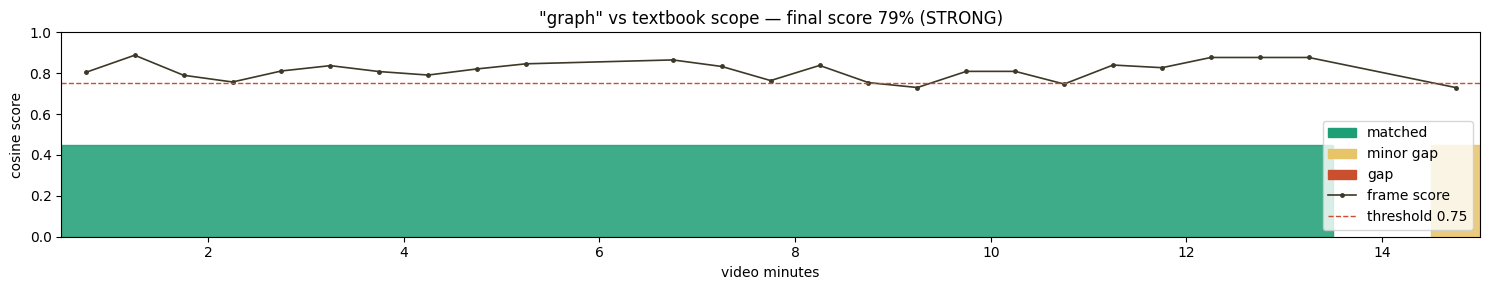

In [10]:
# @title 8. Timeline — the whole video at a glance
fig, ax = plt.subplots(figsize=(15, 3))

for s in segments:
    color = "#1D9E75" if s["kind"] == "matched" else ("#E8C468" if s.get("minor") else "#C94F2E")
    ax.axvspan(s["start_sec"] / 60, s["end_sec"] / 60, ymin=0, ymax=0.45,
               color=color, alpha=0.85)

ax.plot(rows["t_sec"] / 60 + CFG.frame_interval_sec / 120, rows["score"],
        color="#3D3929", lw=1.2, marker=".", ms=5, label="frame score")
ax.axhline(THRESHOLD, color="#C94F2E", ls="--", lw=1, label=f"threshold {THRESHOLD}")

ax.set_xlim(rows["t_sec"].min() / 60, (rows["t_sec"].max() + CFG.frame_interval_sec) / 60)
ax.set_ylim(0, 1); ax.set_xlabel("video minutes"); ax.set_ylabel("cosine score")
ax.legend(loc="lower right", handles=[
    mpatches.Patch(color="#1D9E75", label="matched"),
    mpatches.Patch(color="#E8C468", label="minor gap"),
    mpatches.Patch(color="#C94F2E", label="gap"),
    *ax.get_legend_handles_labels()[0]])
ax.set_title(f'"{report5["video_title"]}" vs textbook scope — final score '
             f'{final:.0%} ({verdict.split()[0]})')
plt.tight_layout()
plt.savefig(Path(CFG.work_dir) / "timeline.png", dpi=150)
plt.show()


In [11]:
# @title 9. Save the coverage report (JSON + Markdown) and zip everything

coverage = {
    "video_title": report5["video_title"],
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "threshold": THRESHOLD,
    "scope": report5["scope"],
    "whole_video": {"final_score": round(final, 4), "verdict": verdict,
                    "time_coverage": round(time_coverage, 4),
                    "topic_coverage": tc, "video_groundedness": vg,
                    "mean_frame_score": round(avg, 4),
                    "duration_total_sec": dur_total,
                    "duration_unscored_sec": dur_unscored,
                    "duration_matched_sec": dur_matched},
    "segments": [{k: v for k, v in s.items() if k != "frame_ids"} for s in segments],
}
Path(CFG.work_dir, "stage6_coverage_report.json").write_text(json.dumps(coverage, indent=2))

lines = [f'# Coverage report — "{report5["video_title"]}"', "",
         f'**Final score: {final:.1%}** — {verdict}', "",
         f'- Time matched: {time_coverage:.1%} ({fmt_dur(dur_matched)} of {fmt_dur(dur_total)})',
         f'- Topic coverage: {tc:.1%} · Groundedness: {vg:.1%} · Threshold: {THRESHOLD}', "",
         "## Matched segments", ""]
for s in segments:
    if s["kind"] == "matched":
        srcs = "; ".join(f'{sec} (pp. {pg}, {bk})' for sec, pg, bk in s["sections"])
        lines.append(f'- **{s["start"]}** for {fmt_dur(s["duration_sec"])} — avg {s["avg_score"]:.2f} — {srcs}')
lines += ["", "## Gap segments", ""]
for s in segments:
    if s["kind"] == "gap":
        tag = " *(minor)*" if s.get("minor") else ""
        closest = "; ".join(f'{sec} (pp. {pg})' for sec, pg, bk in s["sections"][:2])
        lines.append(f'- **{s["start"]}** for {fmt_dur(s["duration_sec"])}{tag} — '
                     f'avg {s["avg_score"]:.2f} (−{s["shortfall"]:.2f}) — closest: {closest}')
Path(CFG.work_dir, "coverage_report.md").write_text("\n".join(lines))

zip_path = shutil.make_archive("/content/stage6_output", "zip", CFG.work_dir)
print("Saved:", zip_path)
# from google.colab import files; files.download(zip_path)


Saved: /content/stage6_output.zip


That's the pipeline complete: **extract → pre-dedup → Qwen content → scoped comparison → coverage report.** The Markdown report is the shareable artifact; the JSON carries every segment with timestamps for anything downstream (e.g. auto-generating "review pp. 165–170" study notes for gap segments).